[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/takechanman1228/marketing-science-in-python/blob/main/notebooks/part5-commercial-analytics/sec5.3_demand_forecasting.ipynb)

# Demand Forecasting with Real Data — Dunnhumby Grocery

This notebook demonstrates the forecasting workflow from **Chapter 5.3**
(Demand Forecasting) on real Dunnhumby grocery panel data, following the
same pipeline:

1. **Statistical baselines** with statsforecast (Naive → AutoETS)
2. **ML model** with mlforecast + LightGBM, using price and promo regressors
3. **Quantile regression** for asymmetric cost optimization
4. **Evaluation** with FVA table, cost-weighted error, and MASE
5. **Hierarchical reconciliation** with hierarchicalforecast (BottomUp,
   MinTrace) so granular forecasts add up to category totals

The input data was prepared by `sec5.3_data_prep.py`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42

from statsforecast import StatsForecast
from statsforecast.models import (
    Naive, SeasonalNaive, AutoETS, AutoARIMA, AutoTheta,
    CrostonOptimized, IMAPA,
)
from statsforecast.utils import ConformalIntervals
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean, RollingStd, ExpandingMean
import lightgbm as lgb
from hierarchicalforecast.utils import aggregate
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import BottomUp, MinTrace

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:
# Colab bootstrap: make the `msbook` helper package importable.
# Local / conda users already have it via `pip install -e .` from the repo root,
# so this is a no-op for them. On Colab it clones the book repo and installs
# msbook in editable mode. (A plain `pip install git+...` is not enough: msbook
# resolves paths by walking up to the repo's _quarto.yml, so it needs the repo
# tree present, which the clone provides.)
import sys
try:
    import msbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess
    _REPO = "https://github.com/takechanman1228/marketing-science-in-python.git"
    subprocess.run(["git", "clone", "-q", _REPO], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e",
                    "marketing-science-in-python"], check=True)
    import msbook  # noqa: F401
from msbook.paths import chapter_images, chapter_artifacts

pd.set_option("display.float_format", "{:.2f}".format)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

IMG_DIR = chapter_images(part="5", chapter="sec5.3")

# Scratch tables (eval / metrics / reconciliation outputs).
# Land under artifacts/ — gitignored, not part of the public artifact set.
_SCRATCH_TABLES = chapter_artifacts(part="5", chapter="sec5.3-demand-forecast") / "tables"
_SCRATCH_TABLES.mkdir(parents=True, exist_ok=True)


def dual_savefig(fig, name, **kw):
    """Single-saver shim. Name retained for call-site stability;
    no local scratch copy is written (see Step 5 of the folder redesign)."""
    kw.setdefault("dpi", 150)
    kw.setdefault("bbox_inches", "tight")
    fig.savefig(IMG_DIR / name, **kw)

In [3]:
# The weekly aggregate is produced by sec5.3_data_prep.py and bundled in the repo
# so this notebook can be re-run without first re-doing the EDA.
from msbook.paths import chapter_generated

_proc = chapter_generated(part="5", chapter="sec5.3-demand-forecast")
df = pd.read_parquet(_proc / "dunnhumby_grocery_weekly.parquet")
df["ds"] = pd.to_datetime(df["ds"])

print(f"Series: {df['unique_id'].nunique()}")
print(f"Date range: {df['ds'].min():%Y-%m-%d} to {df['ds'].max():%Y-%m-%d}")
print(f"Total rows: {len(df):,}")
print(f"Zero-sales weeks: {(df['y'] == 0).sum()} ({(df['y'] == 0).mean():.1%})")
print(f"Commodities: {sorted(df['commodity'].unique())}")
print(f"Stores: {sorted(df['store_id'].unique())}")
df.head()

Series: 35
Date range: 2012-01-02 to 2013-12-09
Total rows: 3,570
Zero-sales weeks: 85 (2.4%)
Commodities: ['BAG SNACKS', 'BAKED BREAD/BUNS/ROLLS', 'CHEESE', 'COLD CEREAL', 'FLUID MILK PRODUCTS', 'SOFT DRINKS', 'YOGURT']
Stores: [np.int64(292), np.int64(356), np.int64(367), np.int64(381), np.int64(406)]


,unique_id,ds,y,effective_price,discount_pct,display_pct,mailer_pct,commodity,store_id
0,BAG SNACKS__292,2012-01-02,0.00,3.00,0.09,0.00,0.00,BAG SNACKS,292
1,BAG SNACKS__292,2012-01-09,6.00,3.00,0.09,0.00,0.00,BAG SNACKS,292
2,BAG SNACKS__292,2012-01-16,5.00,0.98,0.36,0.00,0.00,BAG SNACKS,292
3,BAG SNACKS__292,2012-01-23,0.00,0.98,0.36,0.00,0.00,BAG SNACKS,292
4,BAG SNACKS__292,2012-01-30,6.00,2.76,0.23,0.00,0.00,BAG SNACKS,292


In [4]:
# Hold out last 12 weeks for evaluation
HORIZON = 12
cutoff = df["ds"].max() - pd.Timedelta(weeks=HORIZON - 1)

df_train = df[df["ds"] < cutoff].copy()
df_test = df[df["ds"] >= cutoff].copy()

print(f"Train: {df_train['ds'].min():%Y-%m-%d} to {df_train['ds'].max():%Y-%m-%d}  "
      f"({df_train['ds'].nunique()} weeks)")
print(f"Test:  {df_test['ds'].min():%Y-%m-%d} to {df_test['ds'].max():%Y-%m-%d}  "
      f"({df_test['ds'].nunique()} weeks)")
print(f"Series: {df_train['unique_id'].nunique()} | Horizon: {HORIZON} weeks")

Train: 2012-01-02 to 2013-09-16  (90 weeks)
Test:  2013-09-23 to 2013-12-09  (12 weeks)
Series: 35 | Horizon: 12 weeks


## Statistical Baselines

Following the chapter's Forecast Value Added (FVA) framework, we start
from the simplest models and ask: does each increment of complexity
actually improve accuracy?

Seven models, ordered from simplest to most complex:
1. **Naive** — last observed value repeated forward
2. **SeasonalNaive(52)** — same week last year
3. **AutoETS(52)** — exponential smoothing, automatic component selection
4. **AutoARIMA(52)** — ARIMA with automatic order selection
5. **AutoTheta(52)** — Theta method
6. **CrostonOptimized** — designed for intermittent (zero-heavy) demand
7. **IMAPA** — intermittent demand via multiple temporal aggregation

In [5]:
models_stat = [
    Naive(),
    SeasonalNaive(season_length=52),
    AutoETS(season_length=52),
    AutoARIMA(season_length=52),
    AutoTheta(season_length=52),
    CrostonOptimized(),
    IMAPA(),
]

sf = StatsForecast(
    models=models_stat,
    freq="W-MON",
    n_jobs=1,
)
sf.fit(df_train[["unique_id", "ds", "y"]])
fcst_stat = sf.predict(h=HORIZON)

print(f"Statistical forecasts: {fcst_stat.shape}")
fcst_stat.head()

Statistical forecasts: (420, 9)


,unique_id,ds,Naive,SeasonalNaive,AutoETS,AutoARIMA,AutoTheta,CrostonOptimized,IMAPA
0,BAG SNACKS__292,2013-09-23,21.00,16.00,16.49,11.69,15.90,14.83,14.87
1,BAG SNACKS__292,2013-09-30,21.00,26.00,16.49,13.70,16.00,14.83,14.87
2,BAG SNACKS__292,2013-10-07,21.00,24.00,16.49,15.42,16.10,14.83,14.87
3,BAG SNACKS__292,2013-10-14,21.00,11.00,16.49,15.42,16.20,14.83,14.87
4,BAG SNACKS__292,2013-10-21,21.00,18.00,16.49,15.42,16.30,14.83,14.87


### Probabilistic Forecasts

Point forecasts are insufficient for decisions that depend on uncertainty —
safety stock, for example, is a function of both the forecast and its
uncertainty. statsforecast produces prediction intervals via conformal
prediction, a distribution-free method that calibrates intervals from
cross-validation residuals.

In [6]:
fcst_prob = sf.forecast(
    df=df_train[["unique_id", "ds", "y"]],
    h=HORIZON,
    level=[80, 95],
    prediction_intervals=ConformalIntervals(h=HORIZON, n_windows=3),
)
print(f"Probabilistic forecast columns:\n  {list(fcst_prob.columns)}")

Probabilistic forecast columns:
  ['unique_id', 'ds', 'Naive', 'Naive-lo-95', 'Naive-lo-80', 'Naive-hi-80', 'Naive-hi-95', 'SeasonalNaive', 'SeasonalNaive-lo-95', 'SeasonalNaive-lo-80', 'SeasonalNaive-hi-80', 'SeasonalNaive-hi-95', 'AutoETS', 'AutoETS-lo-95', 'AutoETS-lo-80', 'AutoETS-hi-80', 'AutoETS-hi-95', 'AutoARIMA', 'AutoARIMA-lo-95', 'AutoARIMA-lo-80', 'AutoARIMA-hi-80', 'AutoARIMA-hi-95', 'AutoTheta', 'AutoTheta-lo-80', 'AutoTheta-hi-80', 'AutoTheta-lo-95', 'AutoTheta-hi-95', 'CrostonOptimized', 'CrostonOptimized-lo-95', 'CrostonOptimized-lo-80', 'CrostonOptimized-hi-80', 'CrostonOptimized-hi-95', 'IMAPA', 'IMAPA-lo-95', 'IMAPA-lo-80', 'IMAPA-hi-80', 'IMAPA-hi-95']


## ML Model with Price and Promotion Regressors

LightGBM can incorporate **causal regressors** — features known at
forecast time. In grocery retail, promotional calendars are set 4–8 weeks
ahead, and price changes are scheduled. These are planned inputs, not
leakage.

Three regressors:
- `effective_price` — average price per unit (varies with discounts)
- `display_pct` — fraction of products on in-store display
- `mailer_pct` — fraction of products featured in mailer/flyer

In [7]:
# Log-transform to reduce spike influence on RMSE-optimized models.
# Only df_train is transformed: the full df is never read in log space (it is
# split into df_train / df_test above, and df_test keeps original units), so
# transforming + restoring it was a no-op round trip.
df_train["y_original"] = df_train["y"].copy()
df_train["y"] = np.log1p(df_train["y"])

mlf = MLForecast(
    models={
        "LightGBM": lgb.LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            min_child_samples=20,
            random_state=SEED,
            verbosity=-1,
        ),
    },
    freq="W-MON",
    lags=[1, 4, 12, 52],
    lag_transforms={
        1: [ExpandingMean()],
        4: [RollingMean(window_size=4), RollingStd(window_size=4)],
    },
    date_features=["month", "week"],
)

In [8]:
# Fit with price and promo regressors + static categorical features
train_cols = ["unique_id", "ds", "y",
              "effective_price", "display_pct", "mailer_pct",
              "commodity", "store_id"]
train_fit = df_train[train_cols].copy()
train_fit["commodity"] = train_fit["commodity"].astype("category")
train_fit["store_id"] = train_fit["store_id"].astype("category")

mlf.fit(train_fit, static_features=["commodity", "store_id"])

MLForecast(models=[LightGBM], freq=W-MON, lag_features=['lag1', 'lag4', 'lag12', 'lag52', 'expanding_mean_lag1', 'rolling_mean_lag4_window_size4', 'rolling_std_lag4_window_size4'], date_features=['month', 'week'], num_threads=1)

**Future price and promo assumption:** For the test period, we use actual
values from the held-out data — simulating the common case where promotional
calendars and price schedules are known in advance. In production, if future
values are unknown, use the last known values as a baseline scenario.

In [9]:
future_df = mlf.make_future_dataframe(h=HORIZON)
future_df = future_df.merge(
    df_test[["unique_id", "ds", "effective_price", "display_pct", "mailer_pct"]],
    on=["unique_id", "ds"],
    how="left",
)
# Fill any missing values with last known from training
for col in ["effective_price", "display_pct", "mailer_pct"]:
    last_vals = (
        df_train.sort_values("ds")
        .groupby("unique_id")[col]
        .last()
    )
    future_df[col] = future_df[col].fillna(
        future_df["unique_id"].map(last_vals)
    )

fcst_ml = mlf.predict(h=HORIZON, X_df=future_df)

# Inverse log-transform and clip to non-negative
fcst_ml["LightGBM"] = np.expm1(fcst_ml["LightGBM"]).clip(lower=0)

# Restore original y for evaluation
df_train["y"] = df_train["y_original"]

print(f"ML forecasts: {fcst_ml.shape}")
fcst_ml.head()

ML forecasts: (420, 3)


,unique_id,ds,LightGBM
0,BAG SNACKS__292,2013-09-23,14.64
1,BAG SNACKS__292,2013-09-30,13.38
2,BAG SNACKS__292,2013-10-07,12.61
3,BAG SNACKS__292,2013-10-14,15.05
4,BAG SNACKS__292,2013-10-21,16.84


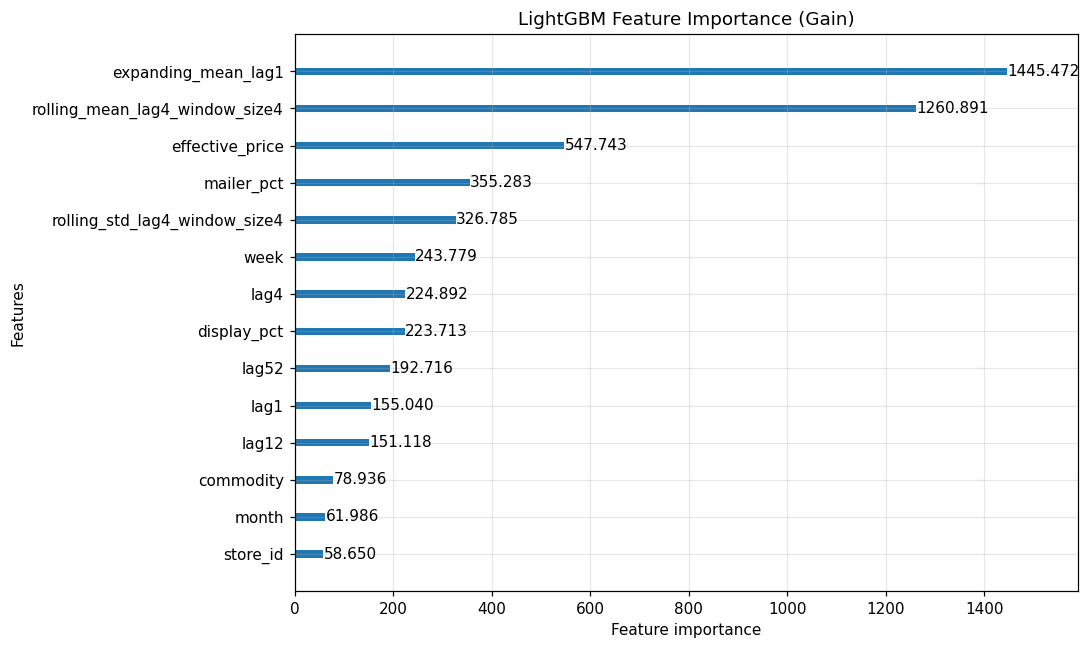

In [10]:
# Feature importance — what did LightGBM learn?
lgb_model = mlf.models_["LightGBM"]
fig, ax = plt.subplots(figsize=(10, 6))
lgb.plot_importance(lgb_model, max_num_features=15, importance_type="gain", ax=ax)
ax.set_title("LightGBM Feature Importance (Gain)")
fig.tight_layout()
dual_savefig(fig, "02_feature_importance.png")
plt.show()
plt.close(fig)

If `effective_price`, `display_pct`, or `mailer_pct` appear among the top
features, the model has learned the demand–price and demand–promotion
relationships. If they do not, check whether the regressors have enough
variation in the training data.

## Quantile Regression for Asymmetric Cost Optimization

The chapter explains that when stockout cost ($c_u$=65) exceeds overstock
cost ($c_o$=30), the optimal forecast targets the 68th percentile
(τ* = 65/95 ≈ 0.68), not the mean. Here we implement that directly
using LightGBM's quantile objective.

In [11]:
# Quantile model targeting tau* = 0.68
df_train["y"] = np.log1p(df_train["y_original"])

mlf_q = MLForecast(
    models={
        "LightGBM_q68": lgb.LGBMRegressor(
            objective="quantile",
            alpha=0.68,
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            min_child_samples=20,
            random_state=SEED,
            verbosity=-1,
        ),
    },
    freq="W-MON",
    lags=[1, 4, 12, 52],
    lag_transforms={
        1: [ExpandingMean()],
        4: [RollingMean(window_size=4), RollingStd(window_size=4)],
    },
    date_features=["month", "week"],
)

train_fit_q = df_train[train_cols].copy()
train_fit_q["commodity"] = train_fit_q["commodity"].astype("category")
train_fit_q["store_id"] = train_fit_q["store_id"].astype("category")

mlf_q.fit(train_fit_q, static_features=["commodity", "store_id"])
fcst_q = mlf_q.predict(h=HORIZON, X_df=future_df)
fcst_q["LightGBM_q68"] = np.expm1(fcst_q["LightGBM_q68"]).clip(lower=0)

df_train["y"] = df_train["y_original"]

# Compare mean vs quantile forecast
mean_avg = fcst_ml["LightGBM"].mean()
q68_avg = fcst_q["LightGBM_q68"].mean()
print(f"Mean forecast average: {mean_avg:.1f} units")
print(f"Q68 forecast average:  {q68_avg:.1f} units")
print(f"Q68 is {(q68_avg / mean_avg - 1) * 100:+.1f}% higher (expected: forecasts slightly high)")

Mean forecast average: 16.3 units
Q68 forecast average:  19.2 units
Q68 is +17.7% higher (expected: forecasts slightly high)


## Rolling Backtest (Cross-Validation)

A single 12-week holdout gives us one sample of forecast accuracy.
Rolling backtest (5 windows × 4-week step) produces far more evaluation
points, making the accuracy estimate more robust.

In [12]:
cv_stat = sf.cross_validation(
    df=df_train[["unique_id", "ds", "y"]],
    h=HORIZON,
    step_size=4,
    n_windows=5,
)
print(f"CV rows: {len(cv_stat):,}")
print(f"CV columns: {list(cv_stat.columns)}")
cv_stat.head()

CV rows: 2,100
CV columns: ['unique_id', 'ds', 'cutoff', 'y', 'Naive', 'SeasonalNaive', 'AutoETS', 'AutoARIMA', 'AutoTheta', 'CrostonOptimized', 'IMAPA']


,unique_id,ds,cutoff,y,Naive,SeasonalNaive,AutoETS,AutoARIMA,AutoTheta,CrostonOptimized,IMAPA
0,BAG SNACKS__292,2013-03-11,2013-03-04,28.00,22.00,5.00,16.94,19.00,18.45,16.78,17.22
1,BAG SNACKS__292,2013-03-18,2013-03-04,17.00,22.00,11.00,16.97,19.23,18.66,16.78,17.22
2,BAG SNACKS__292,2013-03-25,2013-03-04,33.00,22.00,5.00,17.01,19.46,18.87,16.78,17.22
3,BAG SNACKS__292,2013-04-01,2013-03-04,6.00,22.00,11.00,17.04,19.69,19.08,16.78,17.22
4,BAG SNACKS__292,2013-04-08,2013-03-04,21.00,22.00,8.00,17.07,19.92,19.30,16.78,17.22


### utilsforecast.evaluate API

The `utilsforecast` library provides a standardized `evaluate()` function
that computes multiple metrics at once across all series and cutoffs.

In [13]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, smape

eval_api = evaluate(cv_stat, metrics=[mae, rmse, smape])
print("utilsforecast.evaluate — per cutoff × series:")
eval_api.head(10)

utilsforecast.evaluate — per cutoff × series:


,unique_id,cutoff,metric,Naive,SeasonalNaive,AutoETS,AutoARIMA,AutoTheta,CrostonOptimized,IMAPA
0,BAG SNACKS__292,2013-03-04,mae,7.08,10.50,7.55,6.79,6.74,7.69,7.51
1,BAG SNACKS__356,2013-03-04,mae,5.75,7.75,5.65,4.98,5.43,6.14,6.38
2,BAG SNACKS__367,2013-03-04,mae,4.58,8.75,4.62,4.59,4.12,4.61,4.61
3,BAG SNACKS__381,2013-03-04,mae,3.58,27.67,5.55,9.70,5.81,5.81,5.81
4,BAG SNACKS__406,2013-03-04,mae,4.00,5.08,3.56,5.85,4.26,4.10,4.17
5,BAKED BREAD/BUNS/ROLLS__292,2013-03-04,mae,7.17,10.50,11.54,9.32,8.16,7.43,7.49
6,BAKED BREAD/BUNS/ROLLS__356,2013-03-04,mae,5.83,11.33,6.07,6.66,5.50,6.30,6.31
7,BAKED BREAD/BUNS/ROLLS__367,2013-03-04,mae,5.58,7.25,5.25,5.37,5.26,5.33,5.33
8,BAKED BREAD/BUNS/ROLLS__381,2013-03-04,mae,6.50,9.67,6.38,6.44,6.64,6.33,6.33
9,BAKED BREAD/BUNS/ROLLS__406,2013-03-04,mae,6.33,8.00,4.72,4.69,4.64,4.76,4.76


## Evaluation: MASE and Cost-Weighted Error

Following Chapter 5.3's evaluation framework, we evaluate with:
- **MAE, RMSE** — standard metrics
- **MASE** — scaled by naive performance (< 1.0 means better than Naive)
- **Cost-weighted loss** — under-forecast penalized ~2× vs over-forecast

In [14]:
# Merge all forecasts with actuals
actuals = df_test[["unique_id", "ds", "y"]].copy()

all_fcst = fcst_stat.merge(fcst_ml, on=["unique_id", "ds"], how="left")
all_fcst = all_fcst.merge(fcst_q, on=["unique_id", "ds"], how="left")
eval_df = actuals.merge(all_fcst, on=["unique_id", "ds"], how="inner")

print(f"Evaluation rows: {len(eval_df):,}  "
      f"(expect {df_test['unique_id'].nunique()} series × {HORIZON} weeks "
      f"= {df_test['unique_id'].nunique() * HORIZON})")
eval_df.to_csv(_SCRATCH_TABLES / "models_eval_forecasts_vs_actuals.csv", index=False)
eval_df.head()

Evaluation rows: 420  (expect 35 series × 12 weeks = 420)


,unique_id,ds,y,Naive,SeasonalNaive,AutoETS,AutoARIMA,AutoTheta,CrostonOptimized,IMAPA,LightGBM,LightGBM_q68
0,BAG SNACKS__292,2013-09-23,19.00,21.00,16.00,16.49,11.69,15.90,14.83,14.87,14.64,13.25
1,BAG SNACKS__292,2013-09-30,24.00,21.00,26.00,16.49,13.70,16.00,14.83,14.87,13.38,19.22
2,BAG SNACKS__292,2013-10-07,4.00,21.00,24.00,16.49,15.42,16.10,14.83,14.87,12.61,12.43
3,BAG SNACKS__292,2013-10-14,13.00,21.00,11.00,16.49,15.42,16.20,14.83,14.87,15.05,16.48
4,BAG SNACKS__292,2013-10-21,32.00,21.00,18.00,16.49,15.42,16.30,14.83,14.87,16.84,22.61


In [15]:
def cost_weighted_loss(y_true, y_pred, cu=65.0, co=30.0):
    """Asymmetric cost function.
    cu: cost of under-forecasting one unit (lost margin, in dollars).
    co: cost of over-forecasting one unit (holding + markdown, in dollars).
    """
    errors = np.asarray(y_true) - np.asarray(y_pred)
    cost = np.where(
        errors > 0,       # actual > predicted -> under-forecast
        cu * errors,
        co * np.abs(errors),  # actual < predicted -> over-forecast
    )
    return cost.mean()

In [16]:
# Standard metrics + cost-weighted loss per model
model_cols = [c for c in [
    "Naive", "SeasonalNaive", "AutoETS", "AutoARIMA",
    "AutoTheta", "CrostonOptimized", "IMAPA",
    "LightGBM", "LightGBM_q68",
] if c in eval_df.columns]

metrics = {}
for model in model_cols:
    errors = eval_df["y"] - eval_df[model]
    abs_errors = errors.abs()
    metrics[model] = {
        "MAE": abs_errors.mean(),
        "RMSE": np.sqrt((errors ** 2).mean()),
    }

# Proper MASE: per-series, scaled by in-sample one-step naive error
for model in model_cols:
    mase_per_series = []
    for uid in eval_df["unique_id"].unique():
        train_y = df_train[df_train["unique_id"] == uid].sort_values("ds")["y"].values
        naive_scale = np.mean(np.abs(np.diff(train_y)))
        if naive_scale == 0:
            continue
        test_sub = eval_df[eval_df["unique_id"] == uid]
        series_mae = (test_sub["y"] - test_sub[model]).abs().mean()
        mase_per_series.append(series_mae / naive_scale)
    metrics[model]["MASE"] = np.mean(mase_per_series) if mase_per_series else np.nan

# Cost-weighted loss
for model in model_cols:
    if model in eval_df.columns:
        metrics[model]["CostWeighted"] = cost_weighted_loss(
            eval_df["y"].values, eval_df[model].values
        )

metrics_df = pd.DataFrame(metrics).T
metrics_df.index.name = "Model"
metrics_df.to_csv(_SCRATCH_TABLES / "models_metrics_summary.csv", index=True)
metrics_df

,MAE,RMSE,MASE,CostWeighted
Model,,,,
Naive,8.85,11.96,0.99,428.40
SeasonalNaive,10.40,14.68,1.16,446.31
AutoETS,7.37,9.98,0.84,367.22
AutoARIMA,6.74,9.14,0.77,326.06
AutoTheta,6.74,9.05,0.77,312.59
CrostonOptimized,6.71,9.08,0.77,330.80
IMAPA,6.72,9.11,0.77,332.10
LightGBM,6.73,9.40,0.78,367.33
LightGBM_q68,6.72,8.99,0.77,316.36


In [17]:
# Forecast Value Added (FVA) table
fva_rows = []
naive_cwl = metrics.get("Naive", {}).get("CostWeighted", 1.0)

for model in model_cols:
    if model not in metrics:
        continue
    m = metrics[model]
    cwl_improvement = (1 - m["CostWeighted"] / naive_cwl) * 100 if naive_cwl > 0 else 0
    fva_rows.append({
        "Model": model,
        "MAE": m["MAE"],
        "RMSE": m["RMSE"],
        "MASE": m["MASE"],
        "Cost-Weighted Loss": m["CostWeighted"],
        "FVA vs Naive (CWL %)": f"{cwl_improvement:+.1f}%" if model != "Naive" else "(baseline)",
    })

fva_df = pd.DataFrame(fva_rows).set_index("Model")
fva_df.to_csv(_SCRATCH_TABLES / "models_fva_table.csv", index=True)
print("Forecast Value Added Table")
print("=" * 90)
fva_df

Forecast Value Added Table


,MAE,RMSE,MASE,Cost-Weighted Loss,FVA vs Naive (CWL %)
Model,,,,,
Naive,8.85,11.96,0.99,428.40,(baseline)
SeasonalNaive,10.40,14.68,1.16,446.31,-4.2%
AutoETS,7.37,9.98,0.84,367.22,+14.3%
AutoARIMA,6.74,9.14,0.77,326.06,+23.9%
AutoTheta,6.74,9.05,0.77,312.59,+27.0%
CrostonOptimized,6.71,9.08,0.77,330.80,+22.8%
IMAPA,6.72,9.11,0.77,332.10,+22.5%
LightGBM,6.73,9.40,0.78,367.33,+14.3%
LightGBM_q68,6.72,8.99,0.77,316.36,+26.2%


**Interpretation:** Look at the MASE column first — models with MASE < 1.0
beat Naive. Then check the CWL-based FVA column — a positive percentage
means the model reduced business cost vs the Naive baseline. If LightGBM
shows positive FVA, the price and promotion regressors added value. The
quantile model (LightGBM_q68) should have a lower CWL than the mean model
because it targets the business-optimal forecast point.

## Forecast vs Actual — Representative Series

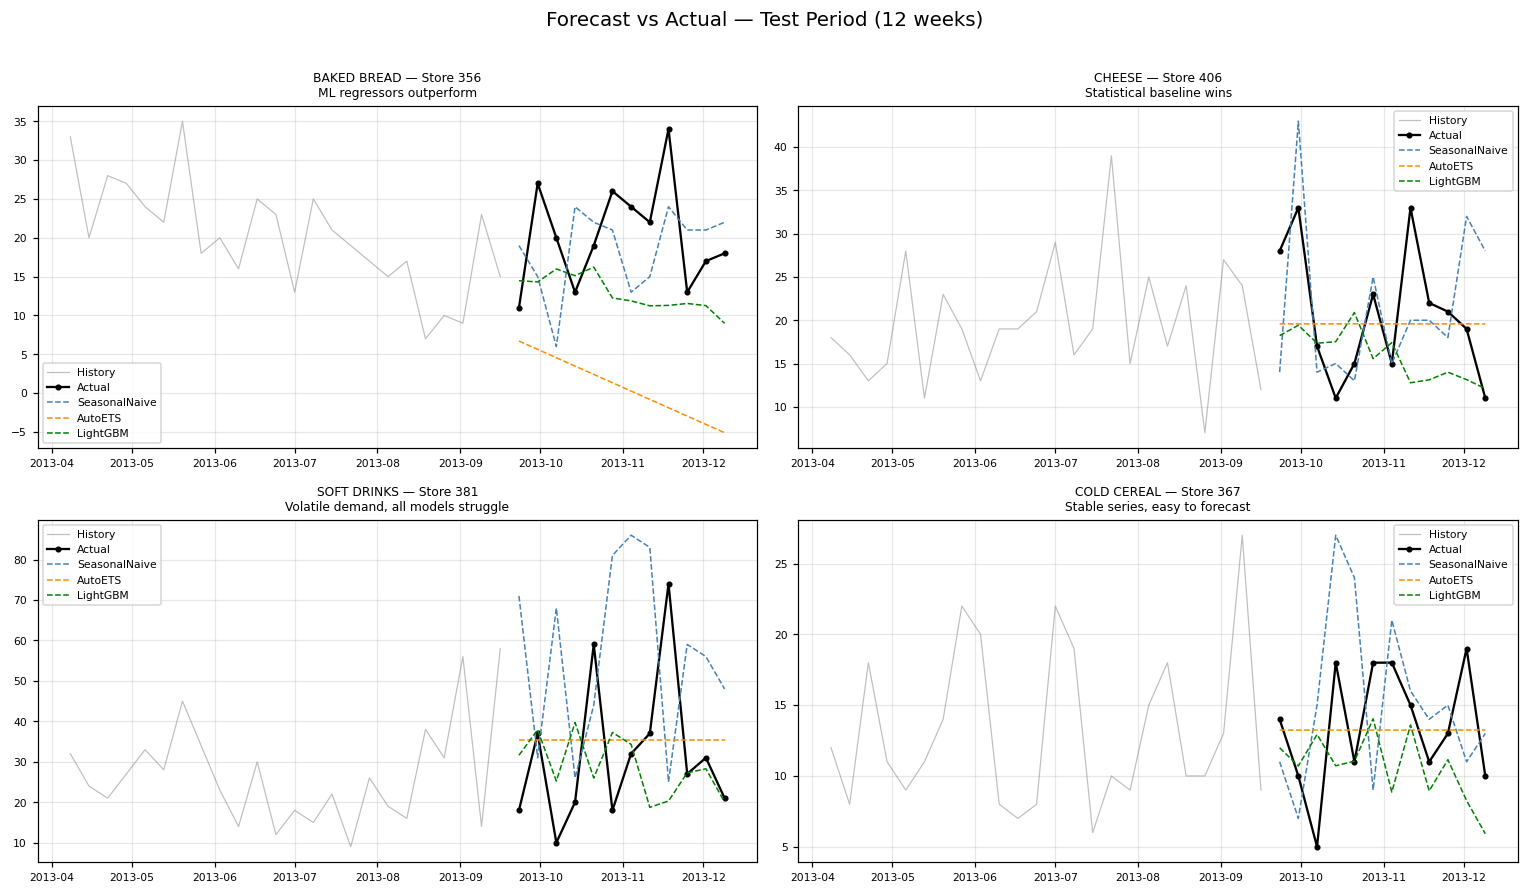

In [18]:
# Select series that tell different stories (not just alphabetical order):
#   1. BAKED BREAD/BUNS/ROLLS__356 — LightGBM dramatically beats AutoETS (regressors help)
#   2. CHEESE__406 — AutoETS beats LightGBM (statistical model wins)
#   3. SOFT DRINKS__381 — hardest series (highest Naive MAE), all models struggle
#   4. COLD CEREAL__367 — quantile regression reduces CWL significantly
plot_ids = [
    "BAKED BREAD/BUNS/ROLLS__356",
    "CHEESE__406",
    "SOFT DRINKS__381",
    "COLD CEREAL__367",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

plot_models = ["SeasonalNaive", "AutoETS", "LightGBM"]
colors = {"SeasonalNaive": "steelblue", "AutoETS": "darkorange",
          "LightGBM": "green"}

for ax, uid in zip(axes, plot_ids):
    sub = eval_df[eval_df["unique_id"] == uid].sort_values("ds")

    # Recent training data for context
    train_tail = df_train[df_train["unique_id"] == uid].sort_values("ds").tail(24)
    ax.plot(train_tail["ds"], train_tail["y"], color="grey", linewidth=0.8,
            alpha=0.5, label="History")

    # Actuals in test period
    ax.plot(sub["ds"], sub["y"], color="black", linewidth=1.5,
            marker="o", markersize=3, label="Actual")

    # Forecasts
    for model in plot_models:
        if model in sub.columns:
            ax.plot(sub["ds"], sub[model], linewidth=1, linestyle="--",
                    color=colors[model], label=model)

    # Descriptive subtitles so each panel tells a story
    story_labels = {
        "BAKED BREAD/BUNS/ROLLS__356": "BAKED BREAD — Store 356\nML regressors outperform",
        "CHEESE__406": "CHEESE — Store 406\nStatistical baseline wins",
        "SOFT DRINKS__381": "SOFT DRINKS — Store 381\nVolatile demand, all models struggle",
        "COLD CEREAL__367": "COLD CEREAL — Store 367\nStable series, easy to forecast",
    }
    ax.set_title(story_labels.get(uid, uid.replace("__", " — Store ")), fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

fig.suptitle("Forecast vs Actual — Test Period (12 weeks)", fontsize=13, y=1.01)
fig.tight_layout()
dual_savefig(fig, "02_forecast_vs_actual.png")
plt.show()
plt.close(fig)

## Quantile vs Mean Forecast Comparison

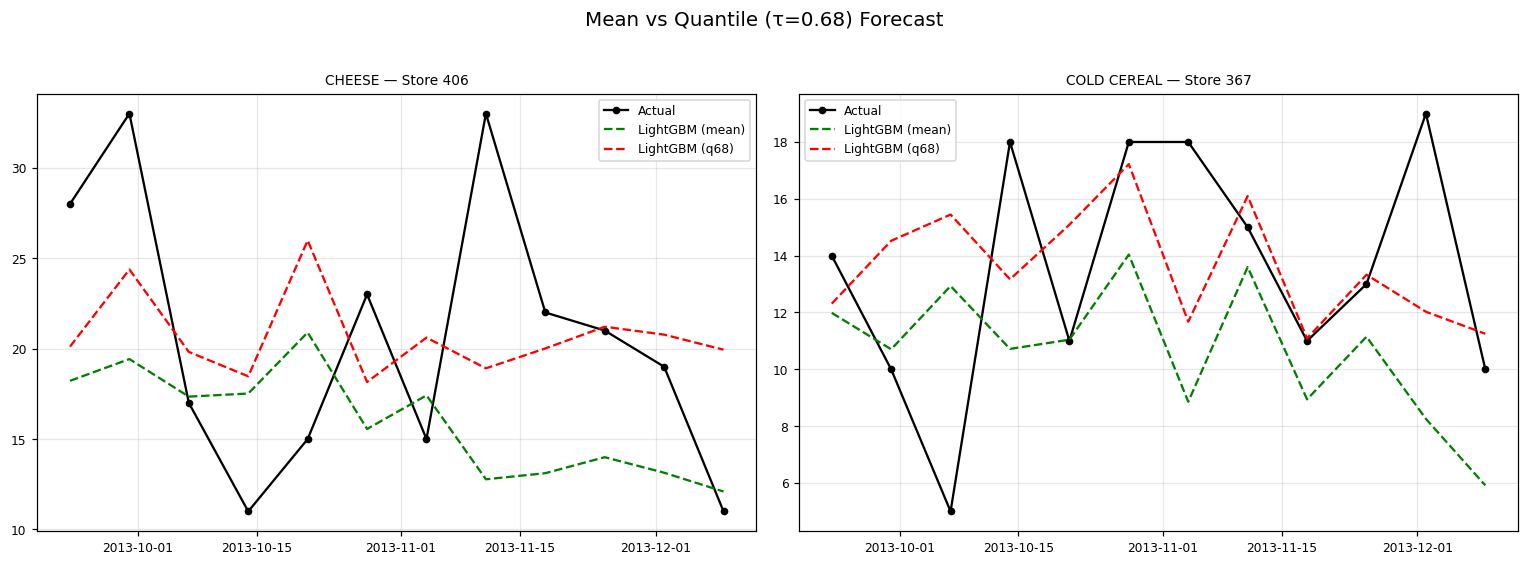

Cost-Weighted Loss:
  LightGBM (mean):   367.3
  LightGBM (q=0.68): 316.4
  Improvement:       +13.9%


In [19]:
# Compare mean and quantile forecasts on series where q68 reduces CWL most
plot_ids_q = ["CHEESE__406", "COLD CEREAL__367"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, uid in zip(axes, plot_ids_q):
    sub = eval_df[eval_df["unique_id"] == uid].sort_values("ds")
    ax.plot(sub["ds"], sub["y"], "ko-", markersize=4, label="Actual")
    ax.plot(sub["ds"], sub["LightGBM"], "--", color="green", label="LightGBM (mean)")
    if "LightGBM_q68" in sub.columns:
        ax.plot(sub["ds"], sub["LightGBM_q68"], "--", color="red",
                label="LightGBM (q68)")
    ax.set_title(uid.replace("__", " — Store "), fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

fig.suptitle("Mean vs Quantile (τ=0.68) Forecast", fontsize=13, y=1.02)
fig.tight_layout()
dual_savefig(fig, "02_quantile_comparison.png")
plt.show()
plt.close(fig)

# Show CWL comparison
if "LightGBM_q68" in metrics:
    mean_cwl = metrics["LightGBM"]["CostWeighted"]
    q68_cwl = metrics["LightGBM_q68"]["CostWeighted"]
    print(f"Cost-Weighted Loss:")
    print(f"  LightGBM (mean):   {mean_cwl:.1f}")
    print(f"  LightGBM (q=0.68): {q68_cwl:.1f}")
    print(f"  Improvement:       {(1 - q68_cwl / mean_cwl) * 100:+.1f}%")

## Probabilistic Forecast Visualization

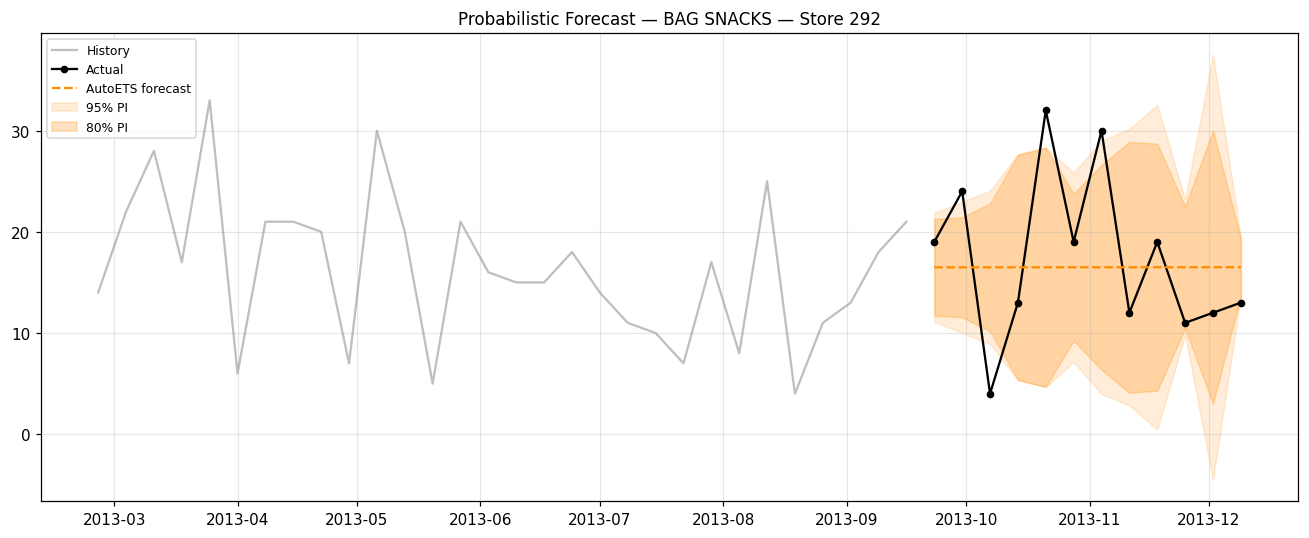

In [20]:
# Show prediction intervals for one series
plot_uid = sorted(df["unique_id"].unique())[0]
prob_sub = fcst_prob[fcst_prob["unique_id"] == plot_uid].sort_values("ds")
train_sub = df_train[df_train["unique_id"] == plot_uid].sort_values("ds").tail(30)
test_sub = df_test[df_test["unique_id"] == plot_uid].sort_values("ds")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_sub["ds"], train_sub["y"], color="grey", alpha=0.5, label="History")
ax.plot(test_sub["ds"], test_sub["y"], "ko-", markersize=4, label="Actual")

# AutoETS point forecast and intervals
model_name = "AutoETS"
ax.plot(prob_sub["ds"], prob_sub[model_name], "--", color="darkorange",
        label=f"{model_name} forecast")
ax.fill_between(prob_sub["ds"],
                prob_sub[f"{model_name}-lo-95"], prob_sub[f"{model_name}-hi-95"],
                alpha=0.15, color="darkorange", label="95% PI")
ax.fill_between(prob_sub["ds"],
                prob_sub[f"{model_name}-lo-80"], prob_sub[f"{model_name}-hi-80"],
                alpha=0.25, color="darkorange", label="80% PI")

ax.set_title(f"Probabilistic Forecast — {plot_uid.replace('__', ' — Store ')}",
             fontsize=11)
ax.legend(fontsize=8)
fig.tight_layout()
dual_savefig(fig, "02_probabilistic_forecast.png")
plt.show()
plt.close(fig)

## Drift Detection

In production, forecast accuracy degrades over time as data distributions
shift. We monitor the 8-week rolling MAE and flag any series where the
rolling error exceeds 2× the historical standard deviation.

In [21]:
# Pick best model from FVA (lowest CWL excluding quantile)
non_q_models = [m for m in model_cols if "q68" not in m]
best_model = min(non_q_models, key=lambda m: metrics[m]["CostWeighted"])
print(f"Best model (lowest CWL): {best_model}")

residuals = eval_df[["unique_id", "ds", "y", best_model]].copy()
residuals["abs_error"] = (residuals["y"] - residuals[best_model]).abs()

ROLL_WINDOW = 8
rolling = (
    residuals.sort_values("ds")
    .groupby("unique_id")["abs_error"]
    .rolling(ROLL_WINDOW, min_periods=4)
    .mean()
)
residuals["rolling_mae"] = rolling.droplevel(0).values

alert_thresholds = residuals.groupby("unique_id")["abs_error"].std() * 2
latest = residuals.groupby("unique_id").tail(1).set_index("unique_id")
alerts = latest["rolling_mae"] > latest.index.map(alert_thresholds)

print(f"Drift detection (rolling {ROLL_WINDOW}-week MAE > 2σ):")
print(f"  Series monitored: {len(alerts)}")
print(f"  Alerts triggered: {alerts.sum()}")
if alerts.any():
    print(f"  Flagged series: {alerts[alerts].index.tolist()}")

Best model (lowest CWL): AutoTheta
Drift detection (rolling 8-week MAE > 2σ):
  Series monitored: 35
  Alerts triggered: 1
  Flagged series: ['COLD CEREAL__356']


## Forecast Guardrails

Business constraints are applied as a post-processing layer — the model
predicts demand, then guardrails enforce operational rules.

In [22]:
WAREHOUSE_CAPACITY = 500   # units per commodity per store per week
MOQ = 1                     # minimum order quantity

forecast_raw = eval_df[["unique_id", "ds", best_model]].copy()
forecast_raw.rename(columns={best_model: "forecast"}, inplace=True)

# 1. Non-negativity
forecast_raw["guardrailed"] = forecast_raw["forecast"].clip(lower=0)

# 2. Inventory capacity ceiling
forecast_raw["guardrailed"] = forecast_raw["guardrailed"].clip(
    upper=WAREHOUSE_CAPACITY * 0.95
)

# 3. Minimum order quantity rounding
forecast_raw["guardrailed"] = (
    (forecast_raw["guardrailed"] / MOQ).round() * MOQ
)

changed = (forecast_raw["forecast"] != forecast_raw["guardrailed"]).sum()
print(f"Guardrails applied to {changed} of {len(forecast_raw)} forecast rows")
print(f"\nSample (first series):")
sample = forecast_raw[forecast_raw["unique_id"] == forecast_raw["unique_id"].iloc[0]]
print(sample[["ds", "forecast", "guardrailed"]].to_string(index=False))

Guardrails applied to 420 of 420 forecast rows

Sample (first series):
        ds  forecast  guardrailed
2013-09-23     15.90        16.00
2013-09-30     16.00        16.00
2013-10-07     16.10        16.00
2013-10-14     16.20        16.00
2013-10-21     16.30        16.00
2013-10-28     16.40        16.00
2013-11-04     16.49        16.00
2013-11-11     16.59        17.00
2013-11-18     16.69        17.00
2013-11-25     16.79        17.00
2013-12-02     16.89        17.00
2013-12-09     16.99        17.00


## Appendix: Iowa Liquor Sales — When Naive Wins

Not every dataset benefits from complex models. The Iowa Liquor Sales
data (state-controlled pricing, 37% zero-sales weeks) is a case where
Naive is the hardest model to beat. This is FVA in action: the framework
correctly tells you not to deploy complexity when it adds no value.

In [23]:
# Iowa comparison (if data is available)
iowa_path = str(_proc / "iowa_vodka_weekly.parquet")
if os.path.exists(iowa_path):
    df_iowa = pd.read_parquet(iowa_path)
    df_iowa["ds"] = pd.to_datetime(df_iowa["ds"])

    # Zero-fill
    all_weeks = pd.date_range(df_iowa["ds"].min(), df_iowa["ds"].max(), freq="W-MON")
    uids_iowa = df_iowa["unique_id"].unique()
    full_idx = pd.MultiIndex.from_product(
        [uids_iowa, all_weeks], names=["unique_id", "ds"]
    )
    df_iowa = df_iowa.set_index(["unique_id", "ds"]).reindex(full_idx).reset_index()
    df_iowa["y"] = df_iowa["y"].fillna(0)

    cutoff_iowa = df_iowa["ds"].max() - pd.Timedelta(weeks=HORIZON - 1)
    train_iowa = df_iowa[df_iowa["ds"] < cutoff_iowa]
    test_iowa = df_iowa[df_iowa["ds"] >= cutoff_iowa]

    sf_iowa = StatsForecast(
        models=[Naive(), AutoTheta(season_length=52)],
        freq="W-MON", n_jobs=1,
    )
    sf_iowa.fit(train_iowa[["unique_id", "ds", "y"]])
    fcst_iowa = sf_iowa.predict(h=HORIZON)

    eval_iowa = test_iowa[["unique_id", "ds", "y"]].merge(
        fcst_iowa, on=["unique_id", "ds"]
    )
    iowa_naive_mae = (eval_iowa["y"] - eval_iowa["Naive"]).abs().mean()
    iowa_theta_mae = (eval_iowa["y"] - eval_iowa["AutoTheta"]).abs().mean()

    print("Iowa Liquor Sales — FVA Summary")
    print("=" * 50)
    print(f"  Naive MAE:     {iowa_naive_mae:.1f}")
    print(f"  AutoTheta MAE: {iowa_theta_mae:.1f}")
    print(f"  AutoTheta MASE: {iowa_theta_mae / iowa_naive_mae:.2f}")
    print(f"  FVA: AutoTheta {'adds' if iowa_theta_mae < iowa_naive_mae else 'does NOT add'} value")
    print(f"\n  Lesson: In state-controlled markets with limited price variation,")
    print(f"  Naive can be the optimal choice. FVA prevents wasted complexity.")
else:
    print("Iowa data not found — skipping comparison.")

Iowa Liquor Sales — FVA Summary
  Naive MAE:     88.1
  AutoTheta MAE: 105.2
  AutoTheta MASE: 1.19
  FVA: AutoTheta does NOT add value

  Lesson: In state-controlled markets with limited price variation,
  Naive can be the optimal choice. FVA prevents wasted complexity.


## Hierarchical Reconciliation

So far we forecast each series independently. But independent forecasts
at different aggregation levels are almost never consistent — the sum of
bottom-level forecasts does not equal the aggregate-level forecast.
**Reconciliation** fixes this, using the `hierarchicalforecast` library.

**Hierarchy:** Total (1) → Commodity (7) → Commodity × Store (35 bottom-level series)

## Define the Hierarchy

The Dunnhumby data has a natural product hierarchy:

- **Total** (1 series) — all commodities, all stores
- **Commodity** (7 series) — SOFT DRINKS, FLUID MILK, CHEESE, etc.
- **Bottom level** (35 series) — commodity × store

`hierarchicalforecast` uses **tags** — a list of column combinations that
define each aggregation level. The `aggregate()` function builds the summing
matrix S and the aggregated time series Y_df.

In [24]:
# Replace "/" in commodity names — hierarchicalforecast uses "/" as hierarchy separator
df["commodity_clean"] = df["commodity"].str.replace("/", "-", regex=False)

df_hier = df[["ds", "y", "commodity_clean", "store_id"]].copy()
df_hier = df_hier.rename(columns={"commodity_clean": "commodity"})
df_hier["store_id"] = df_hier["store_id"].astype(str)
df_hier["Total"] = "Total"

spec = [
    ["Total"],                           # total level (1 series)
    ["Total", "commodity"],              # commodity level (7 series)
    ["Total", "commodity", "store_id"],  # bottom level (35 series)
]

Y_df, S_df, tags = aggregate(
    df=df_hier,
    spec=spec,
)

print(f"Aggregated series: {Y_df['unique_id'].nunique()}")
print(f"Summing matrix shape: {S_df.shape}")
print(f"\nHierarchy levels:")
for level, ids in tags.items():
    print(f"  {level}: {len(ids)} series")

Aggregated series: 43
Summing matrix shape: (43, 36)

Hierarchy levels:
  Total: 1 series
  Total/commodity: 7 series
  Total/commodity/store_id: 35 series


In [25]:
print("Summing matrix (S_df):")
print(f"  Rows (all levels): {S_df.shape[0]}")
# S_df carries a `unique_id` column plus one column per bottom-level series,
# so the bottom-level count is shape[1] - 1, not shape[1].
print(f"  Columns: {S_df.shape[1]} ({S_df.shape[1] - 1} bottom-level series + unique_id)")
print(f"\nFirst few rows of S:")
S_df.head(10)

Summing matrix (S_df):
  Rows (all levels): 43
  Columns: 36 (35 bottom-level series + unique_id)

First few rows of S:


,unique_id,Total/BAG SNACKS/292,Total/BAG SNACKS/356,Total/BAG SNACKS/367,Total/BAG SNACKS/381,Total/BAG SNACKS/406,Total/BAKED BREAD-BUNS-ROLLS/292,Total/BAKED BREAD-BUNS-ROLLS/356,Total/BAKED BREAD-BUNS-ROLLS/367,Total/BAKED BREAD-BUNS-ROLLS/381,...,Total/SOFT DRINKS/292,Total/SOFT DRINKS/356,Total/SOFT DRINKS/367,Total/SOFT DRINKS/381,Total/SOFT DRINKS/406,Total/YOGURT/292,Total/YOGURT/356,Total/YOGURT/367,Total/YOGURT/381,Total/YOGURT/406
0,Total,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
1,Total/BAG SNACKS,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,Total/BAKED BREAD-BUNS-ROLLS,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,Total/CHEESE,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,Total/COLD CEREAL,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5,Total/FLUID MILK PRODUCTS,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
6,Total/SOFT DRINKS,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
7,Total/YOGURT,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00
8,Total/BAG SNACKS/292,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
9,Total/BAG SNACKS/356,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [26]:
HORIZON = 12
cutoff = Y_df["ds"].max() - pd.Timedelta(weeks=HORIZON - 1)

Y_train = Y_df[Y_df["ds"] < cutoff].copy()
Y_test = Y_df[Y_df["ds"] >= cutoff].copy()

print(f"Train: {Y_train['ds'].min():%Y-%m-%d} to {Y_train['ds'].max():%Y-%m-%d}  "
      f"({Y_train['ds'].nunique()} weeks)")
print(f"Test:  {Y_test['ds'].min():%Y-%m-%d} to {Y_test['ds'].max():%Y-%m-%d}  "
      f"({Y_test['ds'].nunique()} weeks)")
print(f"Series: {Y_train['unique_id'].nunique()}")

Train: 2012-01-02 to 2013-09-16  (90 weeks)
Test:  2013-09-23 to 2013-12-09  (12 weeks)
Series: 43


## Base Forecasts

We generate independent forecasts at **every** level of the hierarchy using
AutoETS. Before reconciliation, these forecasts are incoherent — the sum of
bottom-level forecasts does not match the aggregate-level forecasts.

In [27]:
sf_hier = StatsForecast(
    models=[AutoETS(season_length=52)],
    freq="W-MON",
    n_jobs=1,
)
Y_hat_df = sf_hier.forecast(df=Y_train, h=HORIZON, fitted=True)
Y_fitted_df = sf_hier.forecast_fitted_values()

print(f"Base forecasts: {Y_hat_df.shape}")
print(f"Series: {Y_hat_df['unique_id'].nunique()}")
print(f"Fitted values: {Y_fitted_df.shape}")
Y_hat_df.head()

Base forecasts: (516, 3)
Series: 43
Fitted values: (3870, 4)


,unique_id,ds,AutoETS
0,Total,2013-09-23,647.15
1,Total,2013-09-30,647.33
2,Total,2013-10-07,647.49
3,Total,2013-10-14,647.64
4,Total,2013-10-21,647.79


## Reconciliation

Two methods:

- **BottomUp**: use only bottom-level forecasts and aggregate upward. Simple
  but ignores potentially better aggregate-level forecasts.
- **MinTrace (mint_shrink)**: optimally combine forecasts from all levels by
  minimizing the trace of the forecast error covariance matrix. Often
  improves accuracy at all levels, though its optimality depends on the
  quality of the estimated error covariance.

In [28]:
hrec = HierarchicalReconciliation(
    reconcilers=[
        BottomUp(),
        MinTrace(method="mint_shrink"),
    ]
)
Y_rec_df = hrec.reconcile(
    Y_hat_df=Y_hat_df,
    Y_df=Y_fitted_df,
    S_df=S_df,
    tags=tags,
)

print(f"Reconciled forecasts: {Y_rec_df.shape}")
print(f"Columns: {list(Y_rec_df.columns)}")
Y_rec_df.to_csv(_SCRATCH_TABLES / "reconciliation_forecasts.csv", index=False)
Y_rec_df.head()

Reconciled forecasts: (516, 5)
Columns: ['unique_id', 'ds', 'AutoETS', 'AutoETS/BottomUp', 'AutoETS/MinTrace_method-mint_shrink']


,unique_id,ds,AutoETS,AutoETS/BottomUp,AutoETS/MinTrace_method-mint_shrink
0,Total,2013-09-23,647.15,645.32,646.30
1,Total,2013-09-30,647.33,642.77,645.42
2,Total,2013-10-07,647.49,640.23,644.55
3,Total,2013-10-14,647.64,637.70,643.68
4,Total,2013-10-21,647.79,635.16,642.81


## Evaluation: Reconciled vs Unreconciled

We compare base (unreconciled) forecasts against BottomUp and MinTrace
reconciled forecasts using MAE across all hierarchy levels.

In [29]:
eval_hier = Y_test.merge(Y_rec_df, on=["unique_id", "ds"], how="inner")

base_col = "AutoETS"
recon_cols = [c for c in Y_rec_df.columns
              if c not in ("unique_id", "ds") and c != base_col]

results = []
for level_name, level_ids in tags.items():
    level_mask = eval_hier["unique_id"].isin(level_ids)
    sub = eval_hier[level_mask]
    if len(sub) == 0:
        continue

    row = {"Level": level_name, "Series": len(level_ids)}
    for model_col in [base_col] + recon_cols:
        if model_col in sub.columns:
            mae_val = (sub["y"] - sub[model_col]).abs().mean()
            row[f"MAE_{model_col}"] = mae_val
    results.append(row)

results_df = pd.DataFrame(results).set_index("Level")
results_df.to_csv(_SCRATCH_TABLES / "reconciliation_mae_by_level.csv", index=True)
print("MAE by hierarchy level:")
results_df

MAE by hierarchy level:


,Series,MAE_AutoETS,MAE_AutoETS/BottomUp,MAE_AutoETS/MinTrace_method-mint_shrink
Level,,,,
Total,1,100.37,108.57,103.52
Total/commodity,7,21.45,21.70,21.49
Total/commodity/store_id,35,7.37,7.37,7.36


In [30]:
# Verify coherence: bottom-level reconciled forecasts sum to aggregate level
mint_col = [c for c in recon_cols if "MinTrace" in c][0]
bottom_level_name = list(tags.keys())[-1]
total_level_name = list(tags.keys())[0]

bottom_ids = tags[bottom_level_name]
total_ids = tags[total_level_name]

bottom_sum = (
    Y_rec_df[Y_rec_df["unique_id"].isin(bottom_ids)]
    .groupby("ds")[mint_col]
    .sum()
)

total_fcst = (
    Y_rec_df[Y_rec_df["unique_id"].isin(total_ids)]
    .set_index("ds")[mint_col]
)

diff = (bottom_sum - total_fcst).abs()
print(f"Coherence check (MinTrace):")
print(f"  Max |bottom_sum - total|: {diff.max():.6f}")
print(f"  Coherent: {diff.max() < 0.01}")

Coherence check (MinTrace):
  Max |bottom_sum - total|: 0.000000
  Coherent: True


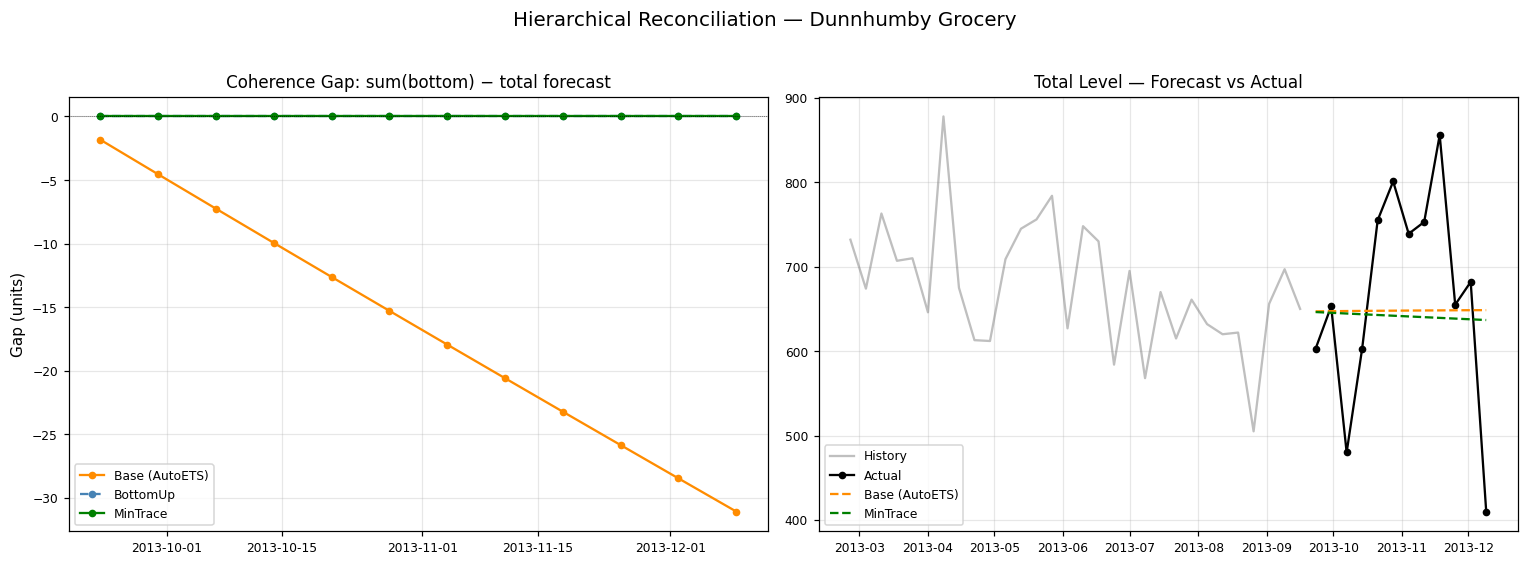

In [31]:
# Visualize reconciliation: coherence gap (before/after) and total-level forecast
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

total_ids = tags[list(tags.keys())[0]]
bottom_ids = tags[list(tags.keys())[-1]]
bu_col = [c for c in recon_cols if "BottomUp" in c][0]

# --- Left panel: Coherence gap over time ---
# sum(bottom forecasts) - total forecast, for Base vs MinTrace
ax = axes[0]
for method_col, label, color, ls in [
    (base_col, "Base (AutoETS)", "darkorange", "-"),
    (bu_col, "BottomUp", "steelblue", "--"),
    (mint_col, "MinTrace", "green", "-"),
]:
    bottom_sum = (
        Y_rec_df[Y_rec_df["unique_id"].isin(bottom_ids)]
        .groupby("ds")[method_col].sum()
    )
    total_fcst = (
        Y_rec_df[Y_rec_df["unique_id"].isin(total_ids)]
        .set_index("ds")[method_col]
    )
    gap = bottom_sum - total_fcst
    ax.plot(gap.index, gap.values, color=color, linestyle=ls,
            marker="o", markersize=4, label=f"{label}")

ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
ax.set_title("Coherence Gap: sum(bottom) − total forecast", fontsize=11)
ax.set_ylabel("Gap (units)")
ax.legend(fontsize=8)
ax.tick_params(labelsize=8)

# --- Right panel: Total-level base vs MinTrace vs actual ---
ax = axes[1]
total_eval = eval_hier[eval_hier["unique_id"].isin(total_ids)].sort_values("ds")
total_train = Y_train[Y_train["unique_id"].isin(total_ids)].sort_values("ds").tail(30)

ax.plot(total_train["ds"], total_train["y"], color="grey", alpha=0.5, label="History")
ax.plot(total_eval["ds"], total_eval["y"], "ko-", markersize=4, label="Actual")
ax.plot(total_eval["ds"], total_eval[base_col], "--",
        color="darkorange", label="Base (AutoETS)")
if mint_col in total_eval.columns:
    ax.plot(total_eval["ds"], total_eval[mint_col], "--",
            color="green", label="MinTrace")
ax.set_title("Total Level — Forecast vs Actual", fontsize=11)
ax.legend(fontsize=8)
ax.tick_params(labelsize=8)

fig.suptitle("Hierarchical Reconciliation — Dunnhumby Grocery", fontsize=13, y=1.02)
fig.tight_layout()
dual_savefig(fig, "03_hierarchical_reconciliation.png")
plt.show()
plt.close(fig)

## Key Takeaways

- **The Nixtla stack handles real grocery data with minimal changes** from
  the code examples in Chapter 5.3.
- **Price and promotion regressors add forecasting value** when the data
  has real variation — LightGBM with `effective_price`, `display_pct`, and
  `mailer_pct` should outperform statistical baselines.
- **Quantile regression (τ=0.68) targets the business-optimal point** when
  stockout costs exceed overstock costs, reducing cost-weighted loss.
- **Log-transforming the target** reduces the influence of demand spikes.
- **FVA is an accountability mechanism** — when models don't add value
  (as with Iowa Liquor Sales), the framework tells you to keep it simple.
- **Reconciliation guarantees coherence.** After MinTrace reconciliation,
  bottom-level forecasts sum exactly to the aggregate total — eliminating
  the "two different numbers" problem between operational and planning teams.
- **MinTrace often improves accuracy at all levels** by borrowing signal
  across the hierarchy, though its performance depends on the quality of
  the estimated error covariance matrix.
- **The summing matrix S encodes the hierarchy.** When a product is added
  or removed (Chapter 5.2), update S and re-run reconciliation.
- **hierarchicalforecast integrates with the Nixtla stack.** Same
  `unique_id / ds / y` format, same StatsForecast models — the only
  addition is the aggregation and reconciliation step.